<a href="https://colab.research.google.com/github/Ali-Hamza-developer/pytorch/blob/main/08_ann_build_fashion_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANN for Fashion-MNIST Classification (PyTorch)

**Ali Hamza**
🔗 [LinkedIn](https://www.linkedin.com/in/alihamzastudent/)

---

Every earlier notebook worked on the breast cancer dataset — **binary** classification (Malignant / Benign) with 30 numeric features. This notebook is a step up:

| | Breast Cancer notebooks | This notebook |
|---|---|---|
| Task | Binary classification | **Multi-class** classification (10 classes) |
| Input | 30 numeric features | **784 pixels** (a 28×28 grayscale image, flattened) |
| Output layer | 1 neuron + `Sigmoid` | **10 neurons**, raw logits (no activation) |
| Loss | `nn.BCELoss()` | `nn.CrossEntropyLoss()` |
| Network | 1 layer (logistic regression) | 2 hidden layers (a real deep ANN) |

**Dataset:** Fashion-MNIST — grayscale images of clothing items, each labeled with one of 10 categories (T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot), stored as `label + 784 pixel columns` per row.

### 🔄 Full pipeline overview

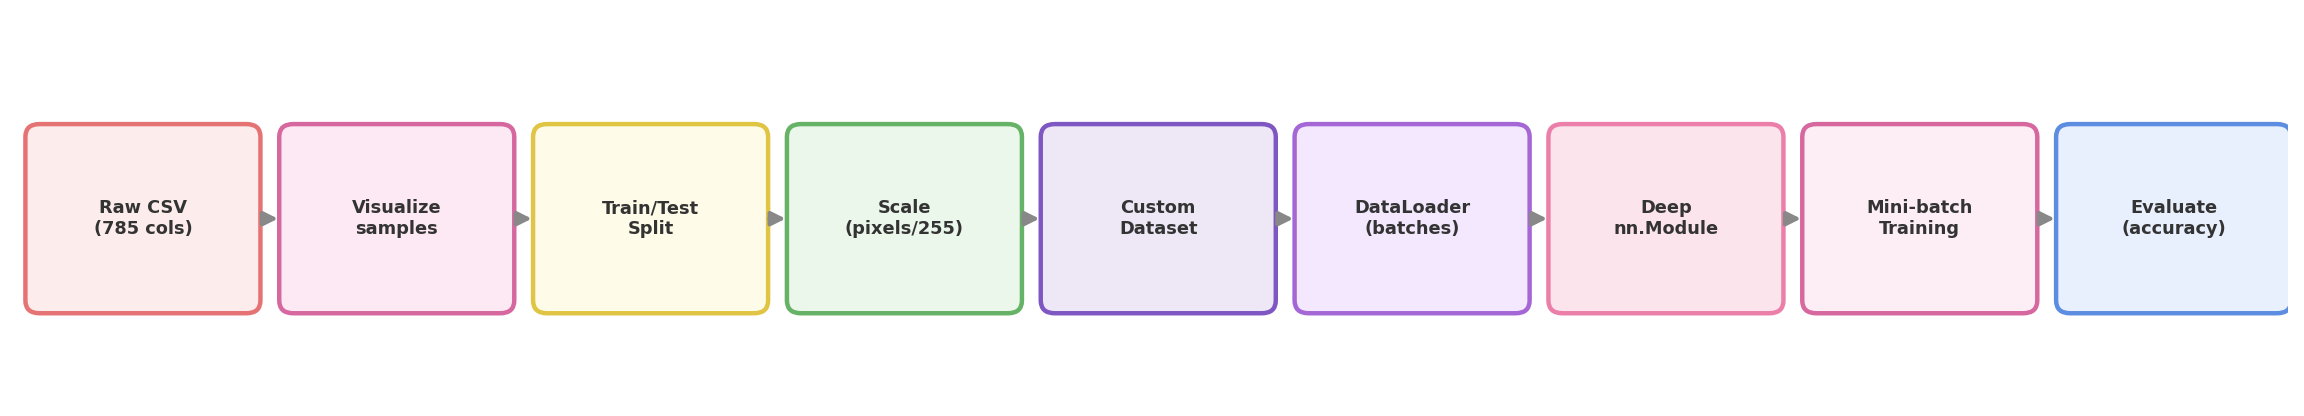

## Step 1 — Import Libraries

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

### Reproducibility

Setting a manual seed means every run initializes weights and shuffles data the same way — useful while debugging, since results won't change between runs just because of randomness.

In [8]:
# Set random seeds for reproducibility
torch.manual_seed(42)

## Step 2 — Load the Dataset

> 📁 **Note:** `fmnist_small.csv` needs to be uploaded to the Colab session (or mounted from Google Drive) before running this cell — it's a local file path, not a URL.

In [9]:
df = pd.read_csv('fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


**Structure of the data:** the first column, `label`, holds a number `0–9` identifying the clothing category. The remaining 784 columns (`pixel1` … `pixel784`) are the grayscale pixel intensities (0–255) of a flattened 28×28 image — `28 × 28 = 784`.

### Preprocessing check — missing values and class balance

Before doing anything else, it's worth confirming there are no missing pixel values, and that the 10 classes are reasonably balanced (an imbalanced dataset would need extra handling, like class weighting, that isn't needed here).

In [10]:
# check for missing values across all columns
df.isnull().sum().sum()

np.int64(0)

In [11]:
# check how many samples exist per class
df['label'].value_counts().sort_index()

,count
label,
0,595
1,590
2,604
3,591
4,595
5,612
6,656
7,620
8,582


## Step 3 — Visualize a Few Samples

Always worth looking at the actual images before training — confirms the reshape logic (`784 → 28×28`) is correct and gives a feel for what the model needs to learn to tell apart.

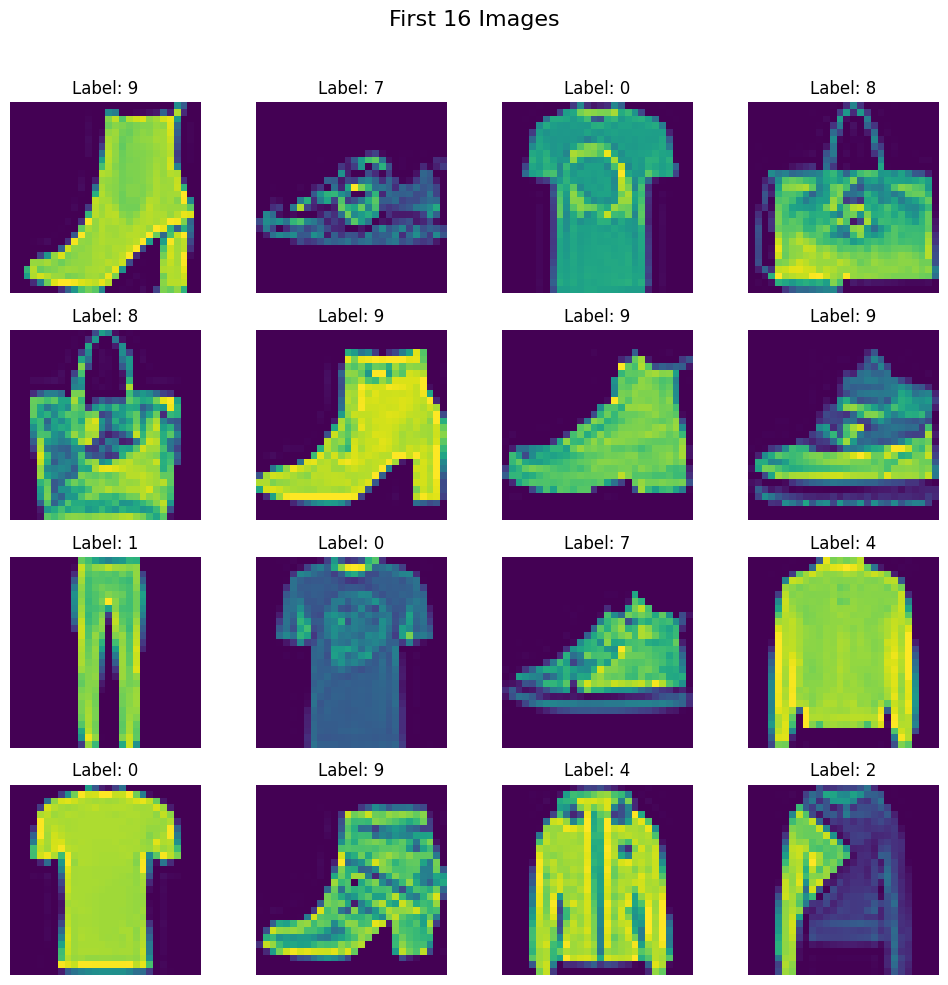

In [12]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

## Step 4 — Train / Test Split

`.values` converts the pandas columns into plain NumPy arrays — `X` is every pixel column, `y` is just the label column.

In [13]:
# train test split

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Step 5 — Feature Scaling

Pixel values range `0–255`. Dividing by `255.0` rescales every pixel into `0–1` — the standard normalization for image data, and much friendlier for the network to train on than raw 0–255 integers.

> 💡 This is simpler than the `StandardScaler` used for the breast cancer dataset because every pixel already shares the same natural scale (0–255) — no need to fit anything, just a fixed division.

In [15]:
# scaling the feautures
X_train = X_train/255.0
X_test = X_test/255.0

In [16]:
X_train

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.0627451, 0.       ,
        0.       ]])

## Step 6 — Custom `Dataset`

Same `Dataset` pattern as before — this time the tensor conversion happens **inside** `__init__` rather than beforehand, so raw NumPy arrays can be passed straight in.

- `dtype=torch.float32` for pixel features
- `dtype=torch.long` for labels — required for `nn.CrossEntropyLoss`, since class labels must be integer indices (`0–9`), not floats

In [17]:
# create CustomDataset Class
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):

    return len(self.features)

  def __getitem__(self, index):

    return self.features[index], self.labels[index]

In [18]:
# create train_dataset object
train_dataset = CustomDataset(X_train, y_train)

In [19]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [20]:
# create test_dataset object
test_dataset = CustomDataset(X_test, y_test)

## Step 7 — Train and Test `DataLoader`s

`shuffle=True` for training (randomize order every epoch), `shuffle=False` for testing (evaluation doesn't need randomness — order doesn't affect accuracy, and keeping it fixed makes debugging easier).

In [21]:
# create train and test loader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## Step 8 — Defining a Deeper Network

This is the first genuinely **deep** network in the series — 2 hidden layers instead of 0 or 1 — sized to handle 784 input pixels down to 10 output classes.

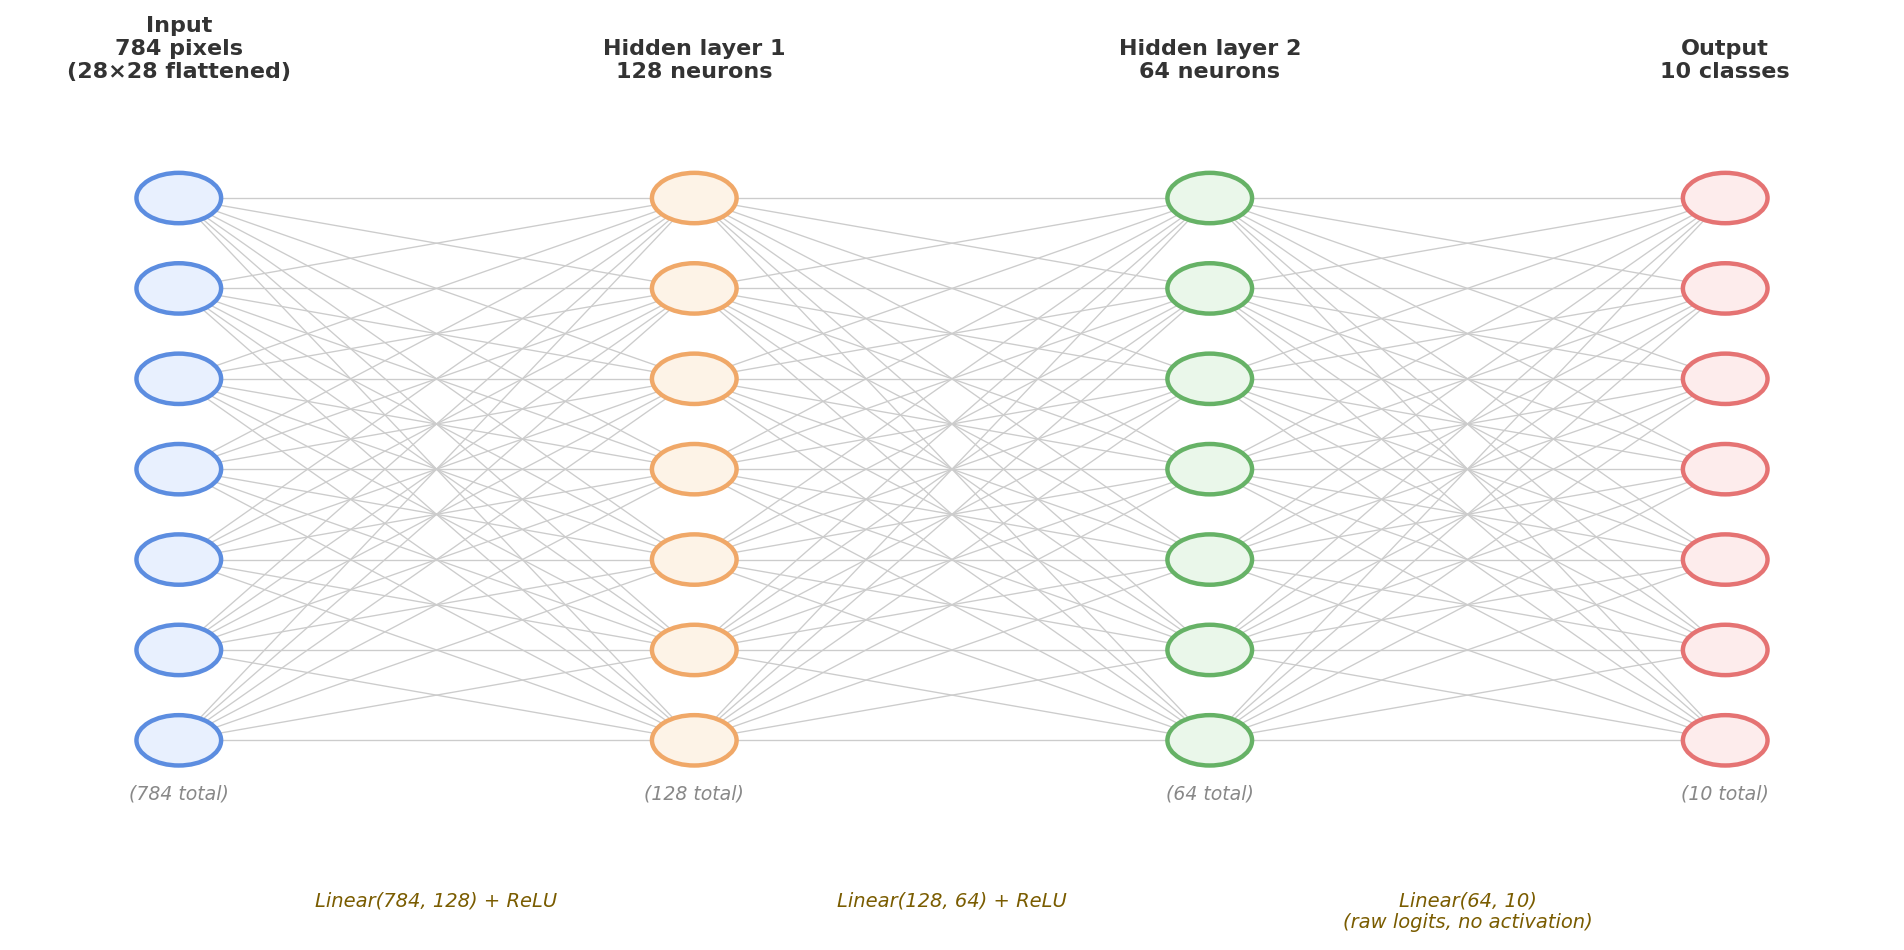

**Important difference from the breast cancer model:** the output layer here is just `nn.Linear(64, 10)` — **no `Sigmoid`, no `Softmax`**. That's intentional:
- `Sigmoid` squashes one number into a 0–1 probability — makes sense for **binary** classification
- For **multi-class** classification, `nn.CrossEntropyLoss` expects **raw, unscaled scores** ("logits") — one per class — and applies `LogSoftmax` internally itself. Adding a `Softmax` layer before it would double up and actually break training.

Each output neuron's value can be read as "how strongly the model favors this class" — the one with the highest raw score wins.

In [22]:
# define NN class
class MyNN(nn.Module):

  def __init__(self, num_features):

    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )

  def forward(self, x):

    return self.model(x)

## Step 9 — Hyperparameters

100 epochs is noticeably more than the 25 used for breast cancer — a harder, multi-class problem with more parameters generally needs more training passes to converge.

In [23]:
# set learning rate and epochs
epochs = 100
learning_rate = 0.1

## Step 10 — Model, Loss Function, Optimizer

`nn.CrossEntropyLoss()` is the standard loss for multi-class classification — it combines `LogSoftmax` and negative log-likelihood loss into a single, numerically stable function, and works directly on the raw logits from the model.

In [24]:
# instatiate the model
model = MyNN(X_train.shape[1])

# loss function
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = optim.SGD(model.parameters(), lr= learning_rate)

### Sanity-check the batch count

With `batch_size=32` and the training set split 80/20 from a "small" Fashion-MNIST subset, this confirms how many batches make up one epoch.

In [25]:
len(train_loader)

150

## Step 11 — Training Pipeline

Structurally identical to the mini-batch breast cancer training loop — same nested epoch/batch cycle:

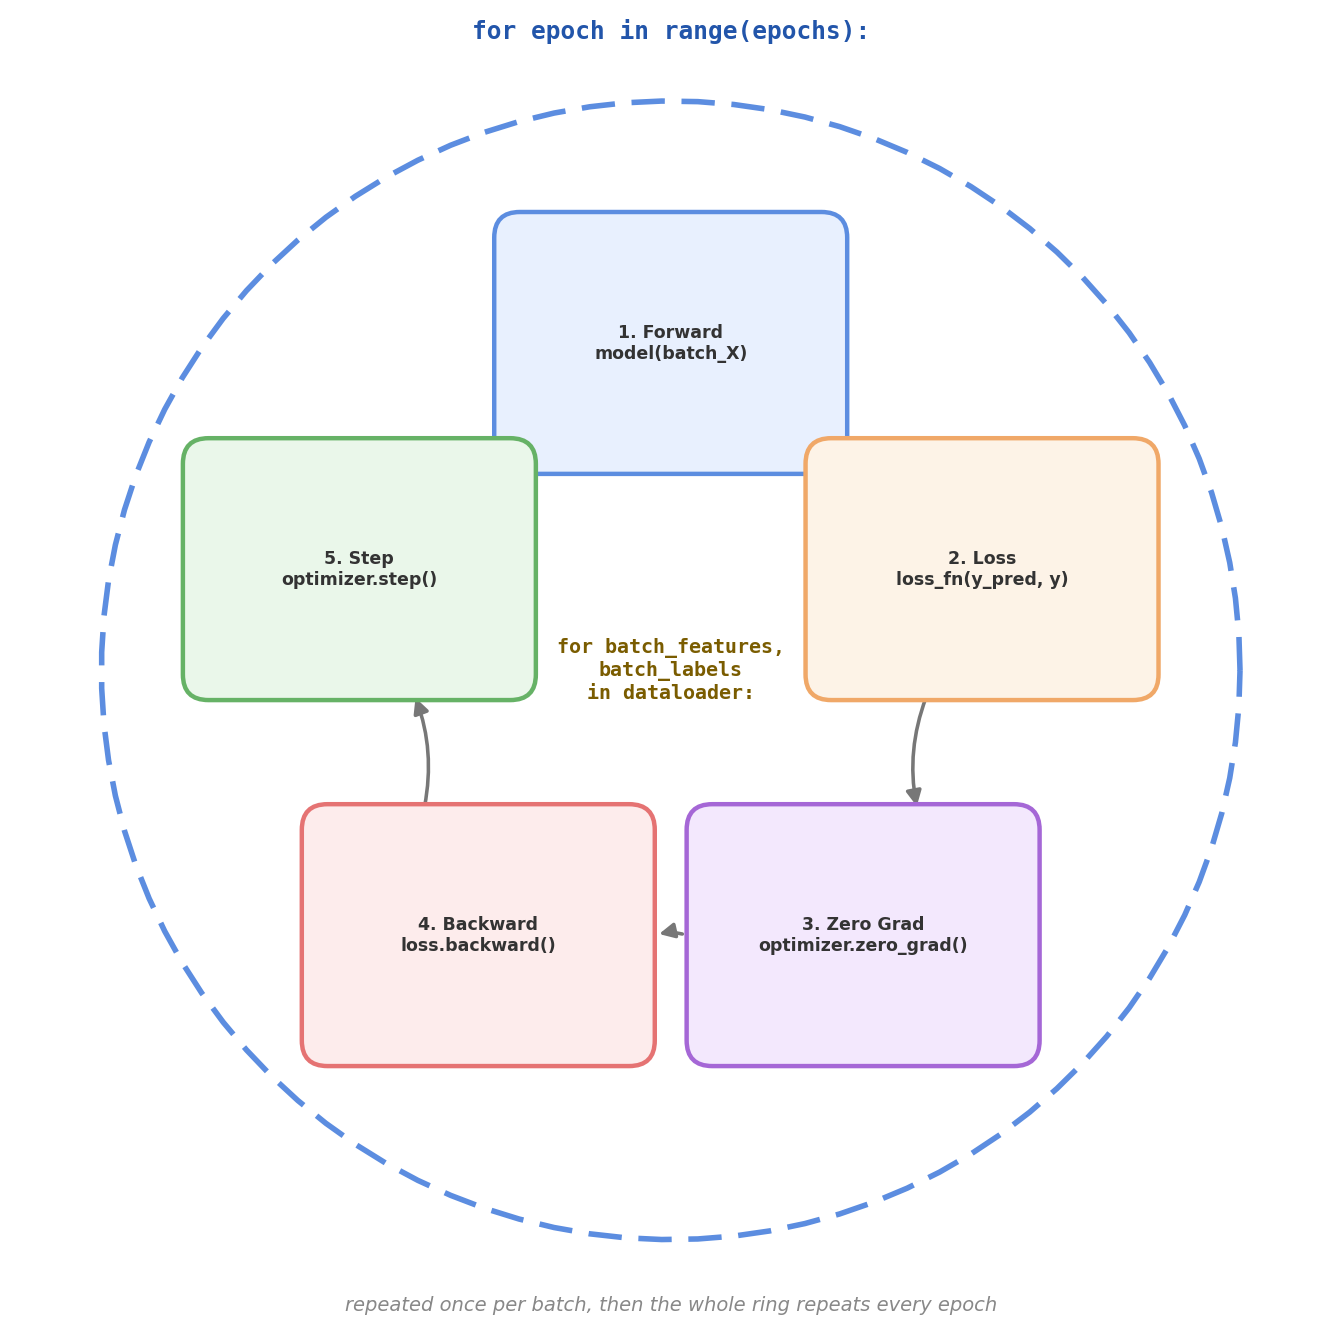

One difference worth noting: `criterion(outputs, batch_labels)` is called directly with the raw label integers (`0–9`), **not** reshaped with `.view(-1, 1)` like the breast cancer notebooks — `CrossEntropyLoss` expects labels as a flat `[batch_size]` tensor of class indices, matching exactly what `DataLoader` already returns.

In [26]:
# training loop

for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    # forward pass
    outputs = model(batch_features)

    # calculate loss
    loss = criterion(outputs, batch_labels)

    # back pass
    optimizer.zero_grad()
    loss.backward()

    # update grads
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')

Epoch: 1 , Loss: 1.3216368440786999
Epoch: 2 , Loss: 0.7793365436792373
Epoch: 3 , Loss: 0.6427524652083715
Epoch: 4 , Loss: 0.5751657336950302
Epoch: 5 , Loss: 0.528180201848348
Epoch: 6 , Loss: 0.49528750121593473
Epoch: 7 , Loss: 0.4602432996034622
Epoch: 8 , Loss: 0.4359459094206492
Epoch: 9 , Loss: 0.41829214423894884
Epoch: 10 , Loss: 0.3984092291692893
Epoch: 11 , Loss: 0.3850264506538709
Epoch: 12 , Loss: 0.3722685620188713
Epoch: 13 , Loss: 0.3477362078428268
Epoch: 14 , Loss: 0.3467242218057315
Epoch: 15 , Loss: 0.3138812760512034
Epoch: 16 , Loss: 0.3126461291313171
Epoch: 17 , Loss: 0.29552092105150224
Epoch: 18 , Loss: 0.2857150869568189
Epoch: 19 , Loss: 0.27084775785605114
Epoch: 20 , Loss: 0.26237100958824155
Epoch: 21 , Loss: 0.25756089876095456
Epoch: 22 , Loss: 0.24232648963729542
Epoch: 23 , Loss: 0.23957946779827277
Epoch: 24 , Loss: 0.2261324493587017
Epoch: 25 , Loss: 0.2233684351791938
Epoch: 26 , Loss: 0.21165308925012746
Epoch: 27 , Loss: 0.21910773759086927
E

> 📉 **What to look for:** with 100 epochs, expect the loss to drop quickly at first and then flatten out close to 0 as the model starts to memorize the training set — that's normal, but worth keeping in mind when checking the test accuracy next (a very low training loss doesn't guarantee equally strong test performance).

## Step 12 — Evaluation

### Switching to eval mode

`model.eval()` puts the model into evaluation mode. It doesn't do anything visible here since this network has no `Dropout` or `BatchNorm` layers (which *do* behave differently during training vs. evaluation) — but it's good practice to always call it before evaluating, since forgetting it is a common silent bug once those layers get added later.

In [27]:
# set model to eval mode
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

### Computing accuracy on the test set

- `torch.no_grad()` — disables gradient tracking, since evaluation doesn't need it
- `torch.max(outputs, 1)` — for each sample, finds the **index** of the highest logit across the 10 output neurons; that index *is* the predicted class (no need for Softmax just to compare which score is largest)
- accuracy is accumulated batch by batch, then divided by the total number of test samples at the end

In [28]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.8325


In [29]:
len(test_loader)

38

---

## ✅ Summary

- First **multi-class** (10-way) classifier in the series, working on image data (784 pixels) instead of tabular features
- First genuinely **deep** network — 2 hidden layers (`784 → 128 → 64 → 10`)
- Output layer has **no activation function** — `nn.CrossEntropyLoss` needs raw logits, and applies `LogSoftmax` internally
- `torch.max(outputs, 1)` replaces the `> 0.5` threshold used for binary classification — it picks the class with the highest score instead of thresholding a single probability
- Same `Dataset` + `DataLoader` + nested training loop pattern as the breast cancer mini-batch notebook — this pattern doesn't change no matter how complex the model or task gets

**Where to go from here:** try adding a confusion matrix to see *which* clothing categories the model confuses most (e.g. Shirt vs. T-shirt are visually similar and often mixed up), or add a `Dropout` layer between the hidden layers to see whether it improves test accuracy over train accuracy.

---
**Ali Hamza** · [LinkedIn](https://www.linkedin.com/in/alihamzastudent/)